In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset:", filename)
print("Shape:", df.shape)

display(df.head())

Saving iris.data.csv to iris.data (1).csv
Dataset: iris.data (1).csv
Shape: (149, 5)


,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df.iloc[:, -1].value_counts())

Columns:
['5.1', '3.5', '1.4', '0.2', 'Iris-setosa']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   5.1          149 non-null    float64
 1   3.5          149 non-null    float64
 2   1.4          149 non-null    float64
 3   0.2          149 non-null    float64
 4   Iris-setosa  149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB
None

Missing Values:
5.1            0
3.5            0
1.4            0
0.2            0
Iris-setosa    0
dtype: int64

Class Distribution:
Iris-setosa
Iris-versicolor    50
Iris-virginica     50
Iris-setosa        49
Name: count, dtype: int64


In [4]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['5.1', '3.5', '1.4', '0.2']

Target:
Iris-setosa

X shape: (149, 4)
y shape: (149,)


In [5]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Encoded classes:")
print(encoder.classes_)

print("\nEncoded target:")
print(y[:10])

Encoded classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Encoded target:
[0 0 0 0 0 0 0 0 0 0]


In [6]:
print(pd.Series(y).value_counts())

1    50
2    50
0    49
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 119
Testing samples: 30


In [8]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

dt_predictions = decision_tree.predict(X_test)

print("Decision Tree predictions:")
print(dt_predictions)

Decision Tree predictions:
[0 2 2 0 1 1 0 1 1 0 1 2 1 1 0 0 2 2 1 2 1 0 2 0 2 2 0 1 2 0]


In [9]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

print("Decision Tree Accuracy:",
      round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 93.33 %


In [10]:
from sklearn.ensemble import BaggingClassifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=10,
    random_state=42
)

bagging_model.fit(X_train, y_train)

bagging_predictions = bagging_model.predict(X_test)

print("Bagging predictions:")
print(bagging_predictions)

Bagging predictions:
[0 2 2 0 1 1 0 1 1 0 1 2 1 1 0 0 2 2 1 2 1 0 2 0 2 2 0 1 2 0]


In [11]:
bagging_accuracy = accuracy_score(
    y_test,
    bagging_predictions
)

print("Bagging Accuracy:",
      round(bagging_accuracy * 100, 2), "%")


Bagging Accuracy: 93.33 %


In [12]:
from sklearn.ensemble import AdaBoostClassifier

boosting_model = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

boosting_model.fit(X_train, y_train)

boosting_predictions = boosting_model.predict(X_test)

print("AdaBoost predictions:")
print(boosting_predictions)

AdaBoost predictions:
[0 2 2 0 1 1 0 1 1 0 1 2 1 1 0 0 2 2 1 2 1 0 2 0 2 2 0 1 2 0]


In [13]:
boosting_accuracy = accuracy_score(
    y_test,
    boosting_predictions
)

print("AdaBoost Accuracy:",
      round(boosting_accuracy * 100, 2), "%")

AdaBoost Accuracy: 93.33 %


In [14]:
print("=" * 50)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 50)

print("Decision Tree :", round(dt_accuracy * 100, 2), "%")
print("Bagging       :", round(bagging_accuracy * 100, 2), "%")
print("AdaBoost      :", round(boosting_accuracy * 100, 2), "%")

MODEL PERFORMANCE COMPARISON
Decision Tree : 93.33 %
Bagging       : 93.33 %
AdaBoost      : 93.33 %


In [15]:
from sklearn.metrics import classification_report

print("=" * 60)
print("DECISION TREE")
print("=" * 60)

print(classification_report(
    y_test,
    dt_predictions,
    target_names=encoder.classes_
))

print("=" * 60)
print("BAGGING")
print("=" * 60)

print(classification_report(
    y_test,
    bagging_predictions,
    target_names=encoder.classes_
))

print("=" * 60)
print("ADABOOST")
print("=" * 60)

print(classification_report(
    y_test,
    boosting_predictions,
    target_names=encoder.classes_
))

DECISION TREE
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

BAGGING
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

ADABOOST
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90    

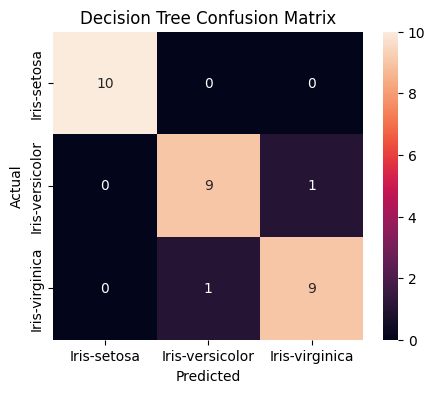

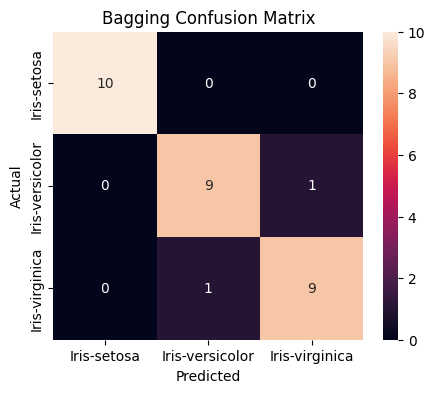

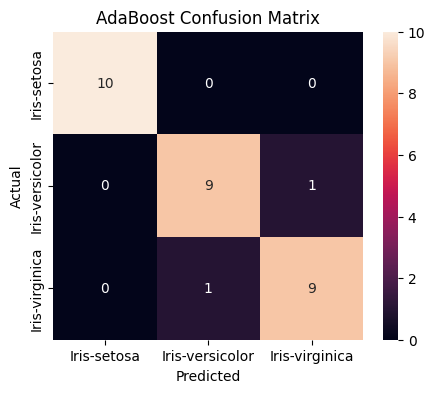

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Decision Tree": dt_predictions,
    "Bagging": bagging_predictions,
    "AdaBoost": boosting_predictions
}

for name, predictions in models.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_
    )

    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [17]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Bagging",
        "AdaBoost"
    ],
    "Accuracy (%)": [
        round(dt_accuracy * 100, 2),
        round(bagging_accuracy * 100, 2),
        round(boosting_accuracy * 100, 2)
    ]
})

display(results)

,Model,Accuracy (%)
0,Decision Tree,93.33
1,Bagging,93.33
2,AdaBoost,93.33
